# Predicting House Prices with Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error,r2_score,mean_squared_error


# loading and performing EDA

In [ ]:
df=pd.read_csv("house price prediction dataset.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# descriptive statistics
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


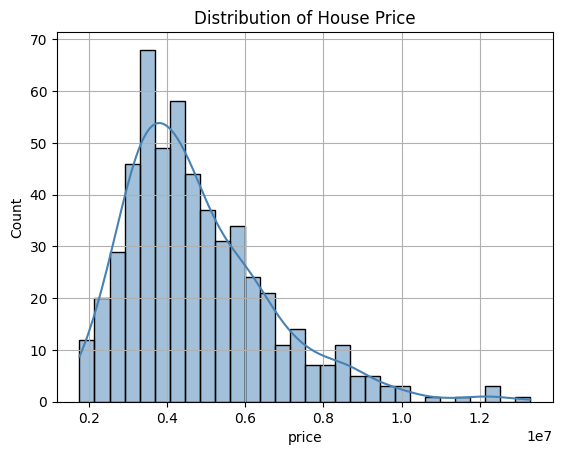

In [ ]:
# distribution of the target variable
sns.histplot(df["price"],bins=30,kde=True,color="steelblue")
plt.title("Distribution of House Price")
plt.grid(True)
plt.show()

In [ ]:
# skewness
print("Price skewness:", round(df["price"].skew(), 2))


Price skewness: 1.21


# Feature Selection Discussion

**Strong expected predictors (numeric, size/quality related):**
- `area` — larger homes almost always command higher prices; usually the single strongest predictor.
- `bedrooms`, `bathrooms`, `stories` — more rooms/floors generally means a bigger, more valuable home, though with diminishing returns.
- `parking` — extra parking spots add convenience value, especially in urban housing markets.

**Categorical predictor with multiple levels:**
- `furnishingstatus` (furnished / semi-furnished / unfurnished) — furnishing level affects price, so it needs one-hot encoding rather than being dropped.

we expect `area` to dominate, followed by `bathrooms`, `airconditioning`, `prefarea`, and `stories`, with the binary amenity flags contributing smaller but real effects.

#  Encode Categorical Features

In [ ]:

df= pd.get_dummies(df, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


# correlation heatmap

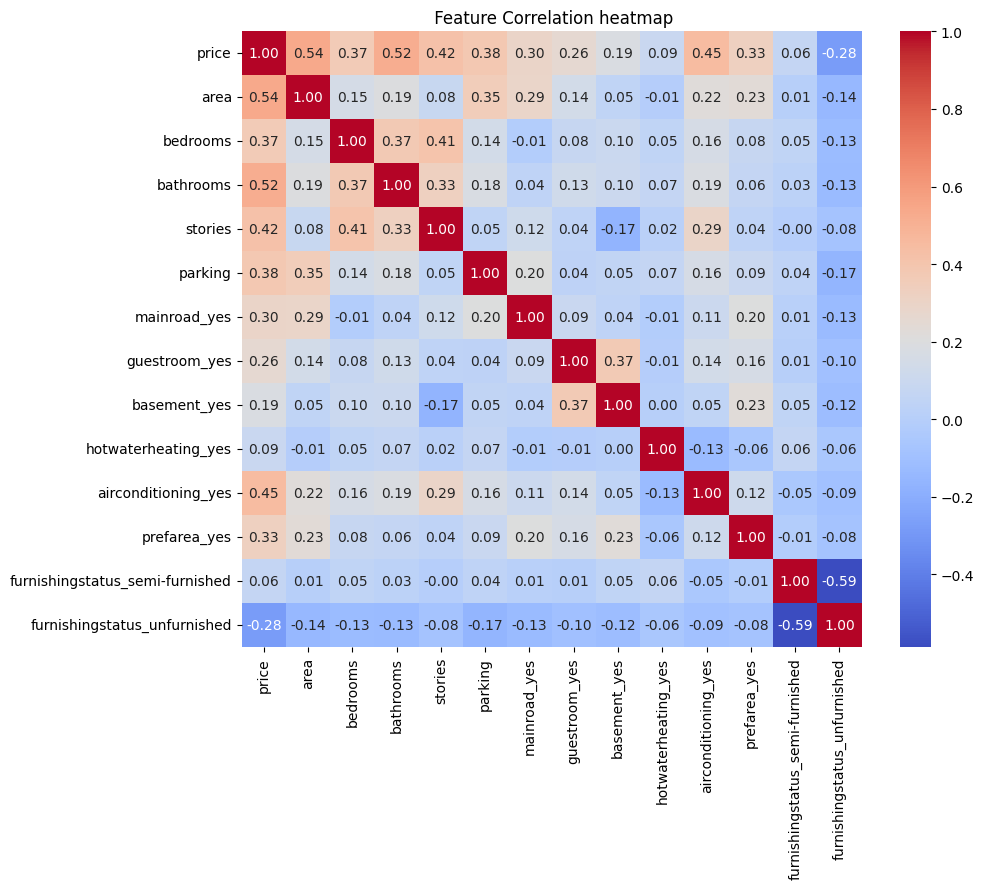

In [ ]:
correlation=df.corr()
# plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True,fmt=".2f", cmap='coolwarm')
plt.title(' Feature Correlation heatmap')
plt.show()


Features ranked by correlation strength with price:

area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
furnishingstatus_unfurnished      -0.280587
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64


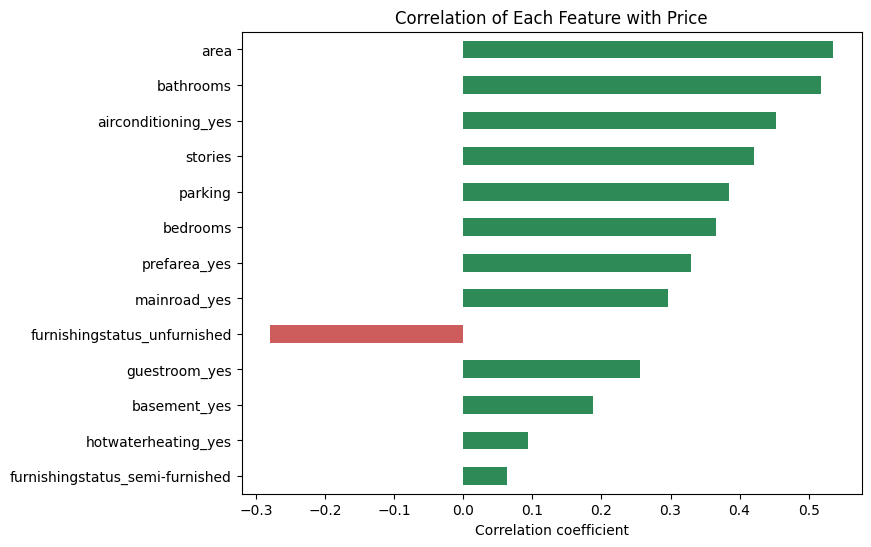

In [ ]:
# Features most correlated with price, ranked
price_corr = correlation["price"].drop("price").sort_values(key=abs, ascending=False)
print("Features ranked by correlation strength with price:\n")
print(price_corr)

plt.figure(figsize=(8, 6))
price_corr.plot(kind="barh", color=["seagreen" if v > 0 else "indianred" for v in price_corr])
plt.title("Correlation of Each Feature with Price")
plt.xlabel("Correlation coefficient")
plt.gca().invert_yaxis()
plt.show()

# Train/Test split

In [ ]:
X=df.drop(columns=["price"])
y=df["price"]
print(f"X.shape:{X.shape}")
print(f"y shape:{y.shape}")

X.shape:(545, 13)
y shape:(545,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("train.shape:",X_train.shape)
print("test shape:",X_test.shape)

train.shape: (436, 13)
test shape: (109, 13)


# Train a Linear Regression model

In [ ]:
lg=LinearRegression()
lg.fit(X_train,y_train)

y_pred=lg.predict(X_test)

print("Model trained. Intercept:", round(lg.intercept_, 2))

Model trained. Intercept: 260032.36


# Evaluate model

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"Root Mean Squared Error:   {rmse:.2f}")
print(f"R-squared (R2):            {r2:.4f}")


print(f"The model explains about {r2*100:.1f}% of the variance in house price.")


Mean Squared Error (MSE):  1754318687330.66
Root Mean Squared Error:   1324506.96
R-squared (R2):            0.6529
The model explains about 65.3% of the variance in house price.


# Actual vs Predicted price

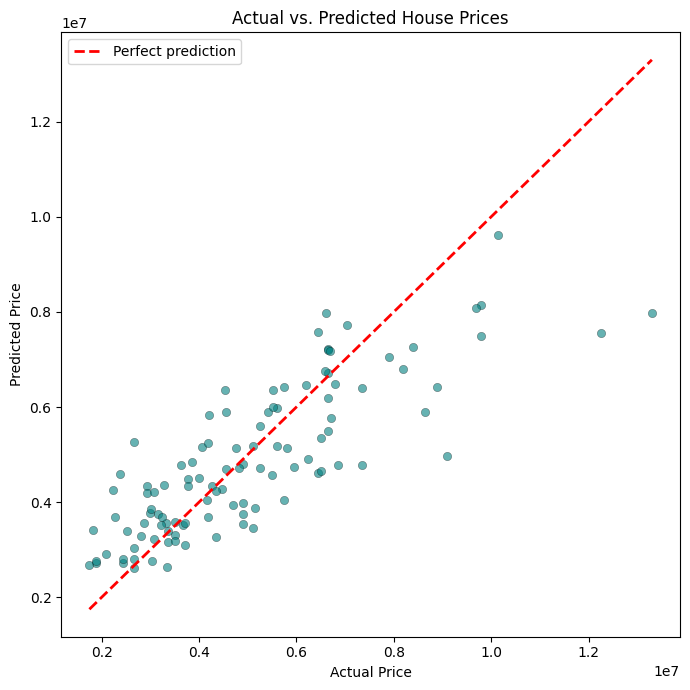

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", edgecolor="k", linewidth=0.3)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()

# Coefficient analysis

furnishingstatus_unfurnished      -4.136451e+05
furnishingstatus_semi-furnished   -1.268818e+05
area                               2.359688e+02
bedrooms                           7.677870e+04
parking                            2.248419e+05
guestroom_yes                      2.316100e+05
mainroad_yes                       3.679199e+05
basement_yes                       3.902512e+05
stories                            4.074766e+05
prefarea_yes                       6.298906e+05
hotwaterheating_yes                6.846499e+05
airconditioning_yes                7.914267e+05
bathrooms                          1.094445e+06
dtype: float64


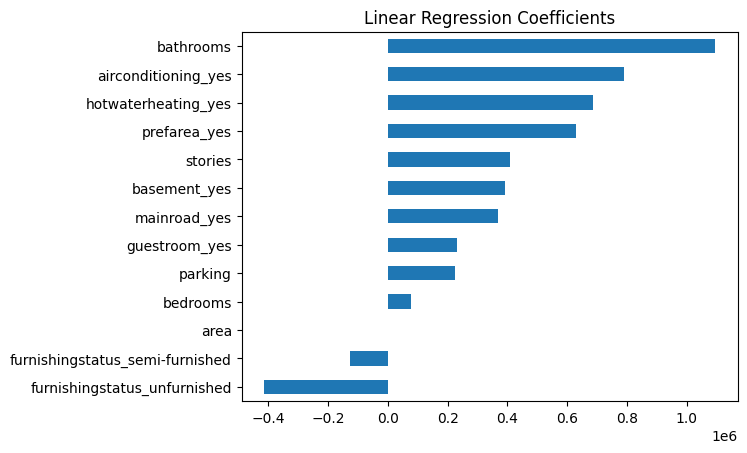

Top positive driver: bathrooms
Top negative driver: furnishingstatus_unfurnished


In [ ]:

coefs = pd.Series(lg.coef_, index=X.columns).sort_values()
print(coefs)
coefs.plot(kind='barh', title="Linear Regression Coefficients")
plt.show()

print("Top positive driver:", coefs.index[-1])
print("Top negative driver:", coefs.index[0])